## Biological Graph

Obtained from: 
https://networkrepository.com/bio-celegans-dir.php


**The human disease network**

In [1]:
import sys
from pathlib import Path

# Add project src/ to Python path so local modules can be imported from notebooks/
ROOT = Path.cwd().parent
SRC = ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f"Added to sys.path: {SRC}")

Added to sys.path: /Users/gabopb/Documents/M1S2/GRAPH/TP/src


In [2]:
import networkx as nx
from graph_analysis import analyze_graph_df, visualize_graph_analysis_large

In [3]:
# Tolerant loader for this Matrix-Market-like edge file
with open("../data/bio-diseasome.mtx", "r", encoding="utf-8") as f:
    # Keep only data lines (drop comments/header lines)
    data_lines = (ln for ln in f if ln.strip() and not ln.startswith("%"))

    # First data line is matrix size metadata: n_rows n_cols nnz
    next(data_lines)

    G = nx.parse_edgelist(
        data_lines,
        nodetype=int,
        data=(("weight", float),),
        create_using=nx.Graph(),
    )

# Optional cleanup: remove self loops from diagonal entries
G.remove_edges_from(nx.selfloop_edges(G))

In [4]:
results = analyze_graph_df(G, name="The human disease network")


=== name ===


'The human disease network'


=== graph_info ===


,metric,value
0,graph_name,The human disease network
1,number_of_nodes,516
2,number_of_edges,1188
3,is_connected,True



=== degree_stats ===


...

,node,betweenness_centrality
0,80,0.469374
1,257,0.409489
2,121,0.278202
3,169,0.237289
4,113,0.200295
...,...,...
511,99,0.000000
512,381,0.000000
513,65,0.000000
514,63,0.000000



=== pagerank ===


,node,pagerank
0,93,0.013145
1,113,0.011095
2,121,0.010391
3,252,0.009033
4,71,0.007898
...,...,...
511,400,0.000524
512,362,0.000524
513,322,0.000517
514,342,0.000514



=== clustering_coefficient ===


,node,clustering_coefficient
0,426,1.0
1,181,1.0
2,424,1.0
3,317,1.0
4,283,1.0
...,...,...
511,466,0.0
512,410,0.0
513,342,0.0
514,91,0.0


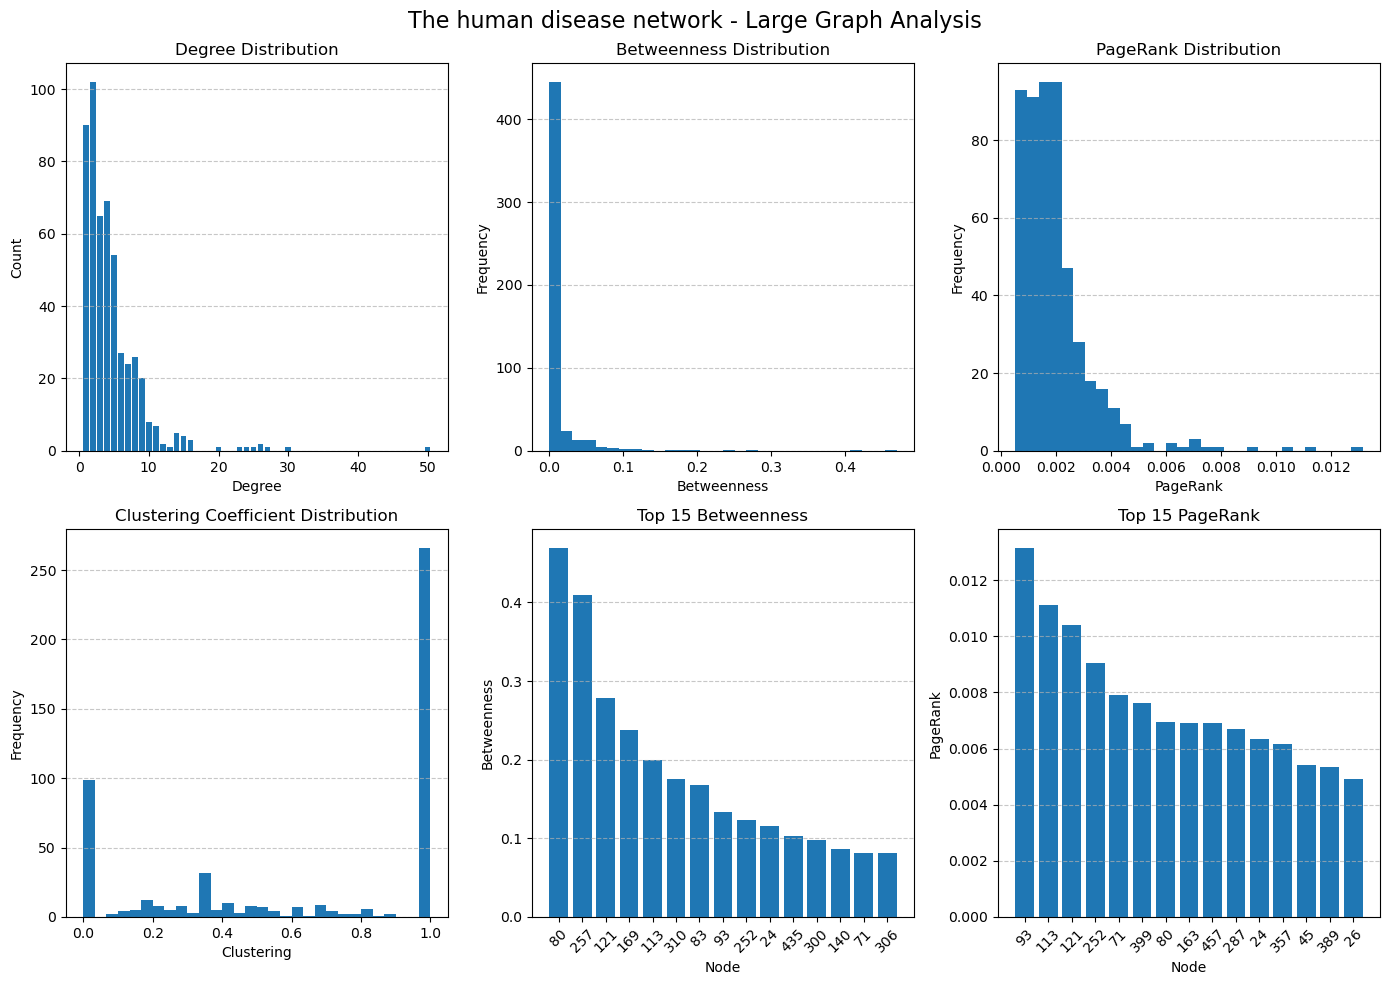

In [5]:
for key, value in results.items():
    print(f"\n=== {key} ===")
    display(value)

visualize_graph_analysis_large(G, results, name="The human disease network")  